In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\harin\OneDrive\Desktop\task_2\Influencer_Campaign_Dataset.csv")
print(df.head())
print(df.tail())
print(df.columns.tolist())
print(df.info())
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
campaign_metrics=['Impressions','Clicks','Conversions','Likes','Shares','Comments','Revenue','Campaign_Spend','Reach']
print(df[campaign_metrics].describe())
df['Engagement']=df['Likes']+df['Comments']+df['Shares']
df['Engagement_rate']=(df['Engagement']/df['Reach'])*100
df['Conversion_rate']=(df['Conversions']/df['Clicks'])*100
df['ROI']=((df['Revenue']-df['Campaign_Spend'])/df['Campaign_Spend'])*100
df['Cost_per_engagement']=df['Campaign_Spend']/df['Engagement']
print(df.head())
df.to_csv("Influencer_Campaign_Cleaned.csv",index=False)

  Campaign_ID    Campaign_Name Influencer_ID Influencer_Name   Platform  \
0   CMP000001       Flash Sale        INF029           Priya   snapchat   
1   CMP000002  Brand Awareness        INF047           Arjun    Twitter   
2   CMP000003       New Launch        INF050           Rahul    YouTube   
3   CMP000004  Brand Awareness        INF022            Riya  Instagram   
4   CMP000005  Brand Awareness        INF036            Riya  Instagram   

  Category  Followers Audience_Group  Gender Campaign_Date  ...  \
0  Fitness     832594          18-24    Male    01-01-2025  ...   
1   Beauty     867573            45+    Male    02-01-2025  ...   
2     Food     773212          18-24   Mixed    03-01-2025  ...   
3     Food     116855          25-34    Male    04-01-2025  ...   
4     Food    1081144            45+  Female    05-01-2025  ...   

   Campaign_Spend  Engagement  Revenue  Engagement_Rate  Conversion_Rate  \
0          135576       51767  4813180            10.69            19.

In [3]:
print("\n---phase2---")
total_campaigns = df["Campaign_ID"].nunique()
print("\nTotal Campaigns :", total_campaigns)

total_reach = df["Reach"].sum()
print("Total Reach :", total_reach)

total_spend = df["Campaign_Spend"].sum()
print("Total Campaign Spend :", total_spend)

total_revenue=df["Revenue"].sum()
print("Total Revenue:",total_revenue)

avg_engagement_rate = df["Engagement_Rate"].mean()
print("Average Engagement Rate : {:.2f}%".format(avg_engagement_rate))

avg_conversion_rate = df["Conversion_Rate"].mean()
print("Average Conversion Rate : {:.2f}%".format(avg_conversion_rate))

avg_roi = df["ROI"].mean()
print("Average ROI : {:.2f}%".format(avg_roi))

avg_cpe = df["Cost_Per_Engagement"].mean()
print("Average Cost Per Engagement : {:.2f}".format(avg_cpe))



---phase2---

Total Campaigns : 824971
Total Reach : 413044840022
Total Campaign Spend : 210460653066
Total Revenue: 421156659986
Average Engagement Rate : 39.50%
Average Conversion Rate : 52.95%
Average ROI : 307.04%
Average Cost Per Engagement : 7.07



---phase 3---


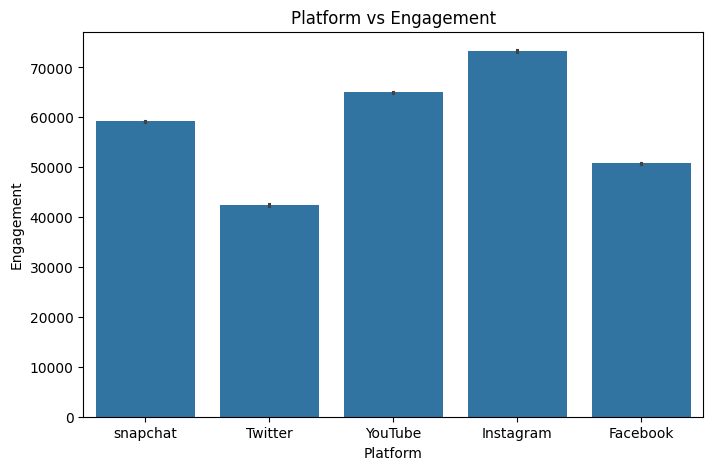

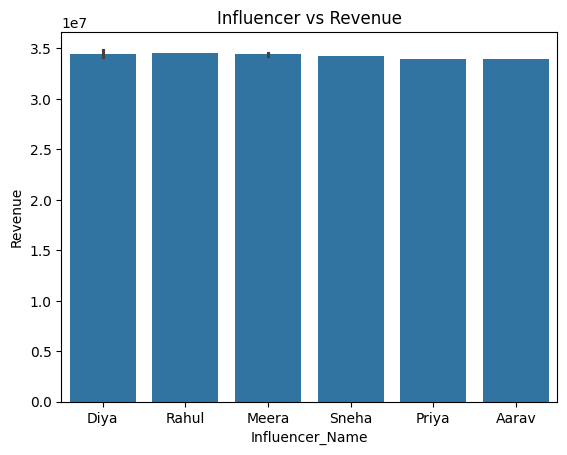

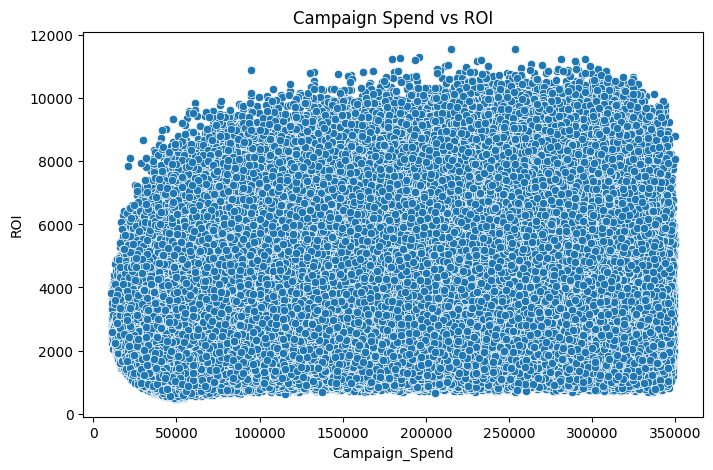

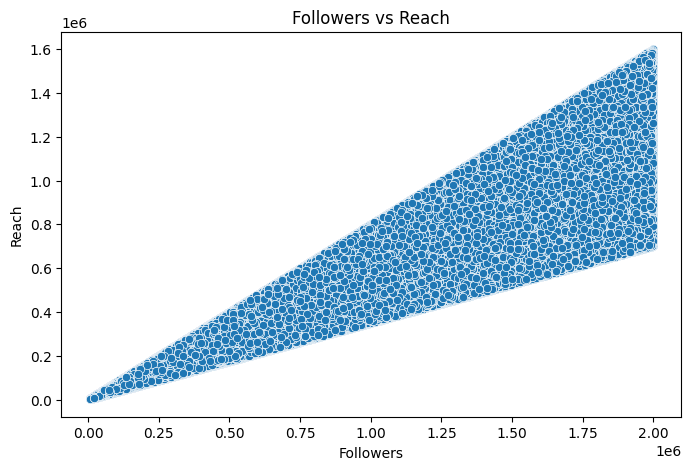

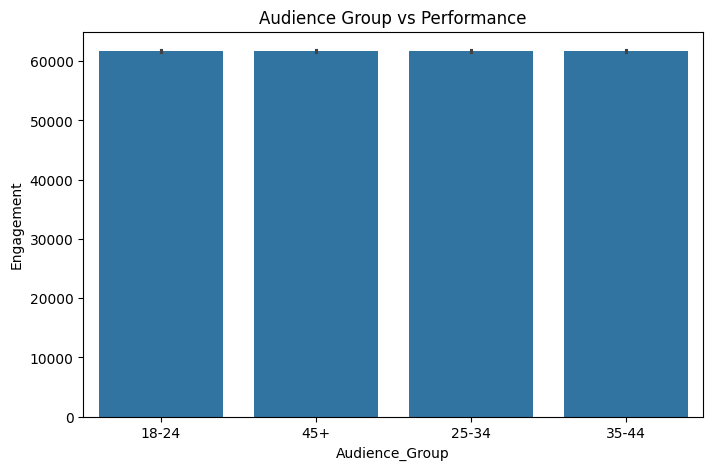

In [6]:
print("\n---phase 3---")
plt.figure(figsize=(8,5))
sns.barplot(x="Platform",y="Engagement",data=df)
plt.title("Platform vs Engagement")
plt.show()

top10=df.nlargest(10,"Revenue")
sns.barplot(x="Influencer_Name", y="Revenue", data=top10)
plt.title("Influencer vs Revenue")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Campaign_Spend", y="ROI", data=df)
plt.title("Campaign Spend vs ROI")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Followers", y="Reach", data=df)
plt.title("Followers vs Reach")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="Audience_Group", y="Engagement", data=df)
plt.title("Audience Group vs Performance")
plt.show()

In [7]:
print("\n----PHASE 4----")

df["Segment"] = "Other"

df.loc[df["ROI"] >= 100, "Segment"] = "High ROI Influencers"

df.loc[df["Followers"] < 100000, "Segment"] = "Micro Influencers"

df.loc[df["Followers"] >= 1000000, "Segment"] = "Mega Influencers"

df.loc[df["Engagement_Rate"] >= 10, "Segment"] = "High Engagement Creators"

average_cost = df["Cost_Per_Engagement"].mean()

df.loc[df["Cost_Per_Engagement"] < average_cost,
       "Segment"] = "Cost Efficient Influencers"

print(df[["Influencer_Name",
          "Followers",
          "ROI",
          "Engagement_Rate",
          "Cost_Per_Engagement",
          "Segment"]].head())


----PHASE 4----
  Influencer_Name  Followers      ROI  Engagement_Rate  Cost_Per_Engagement  \
0           Priya     832594  3450.17            10.69                 2.62   
1           Arjun     867573  5343.04             7.67                 5.06   
2           Rahul     773212  2808.94            10.66                 2.99   
3            Riya     116855  2276.89            12.59                 5.25   
4            Riya    1081144  3068.97            13.12                 2.80   

                      Segment  
0  Cost Efficient Influencers  
1        High ROI Influencers  
2  Cost Efficient Influencers  
3    High Engagement Creators  
4  Cost Efficient Influencers  



---- Phase 5 ----
Total Campaign Spend: 180288842927
Total Revenue: 6497142588922
ROI: 3503.74 %


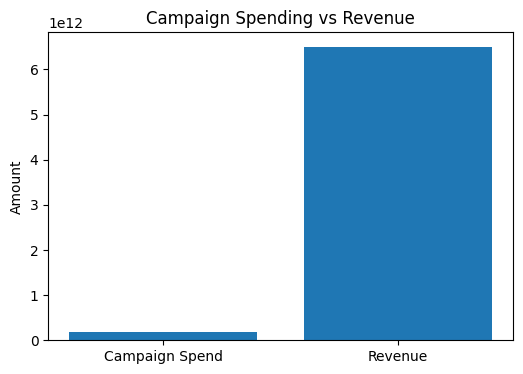

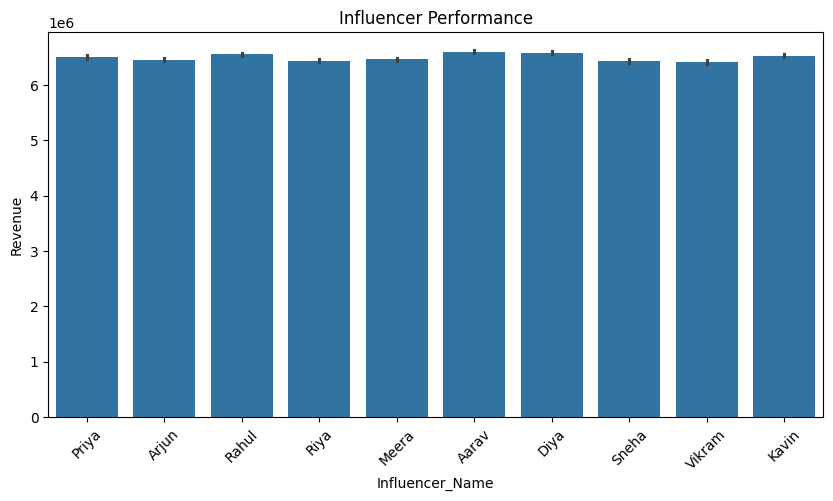

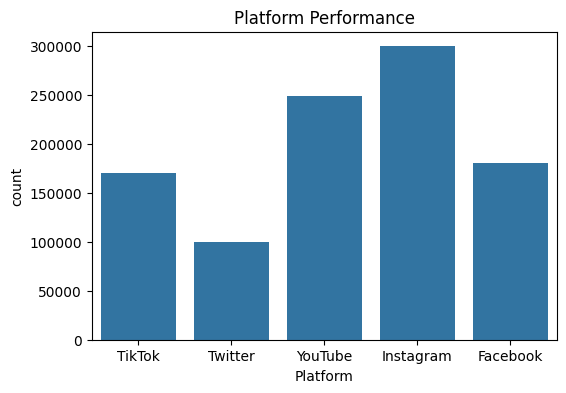

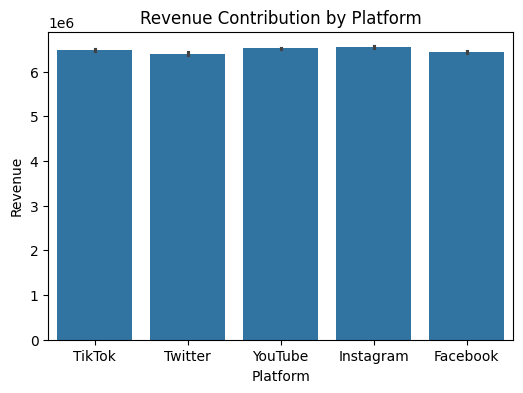

In [10]:
print("\n---- Phase 5 ----")

total_spend = df["Campaign_Spend"].sum()
total_revenue = df["Revenue"].sum()
roi = ((total_revenue - total_spend) / total_spend) * 100

print("Total Campaign Spend:", total_spend)
print("Total Revenue:", total_revenue)
print("ROI:", round(roi, 2), "%")

# Campaign Spending vs Revenue
plt.figure(figsize=(6,4))
plt.bar(["Campaign Spend", "Revenue"], [total_spend, total_revenue])
plt.title("Campaign Spending vs Revenue")
plt.ylabel("Amount")
plt.show()

# Influencer Performance
plt.figure(figsize=(10,5))
sns.barplot(x="Influencer_Name", y="Revenue", data=df)
plt.title("Influencer Performance")
plt.xticks(rotation=45)
plt.show()

# Platform Performance
plt.figure(figsize=(6,4))
sns.countplot(x="Platform", data=df)
plt.title("Platform Performance")
plt.show()

# Revenue Contribution by Platform
plt.figure(figsize=(6,4))
sns.barplot(x="Platform", y="Revenue", data=df)
plt.title("Revenue Contribution by Platform")
plt.show()

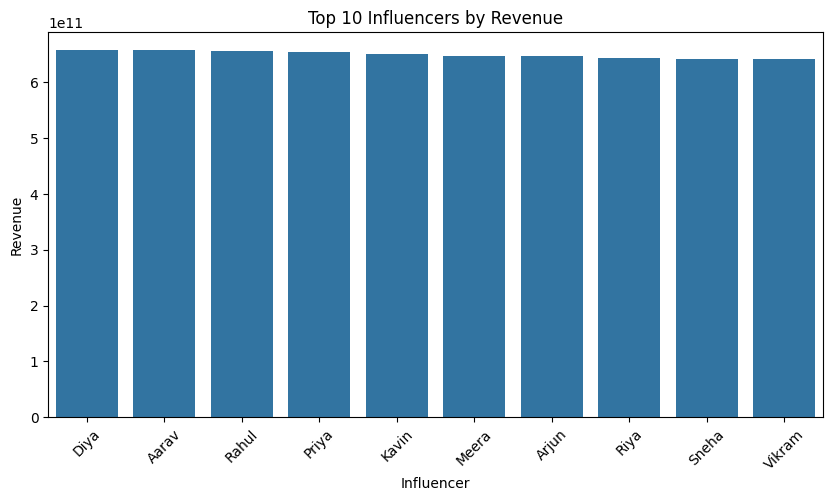

In [11]:
# Top 10 Influencers by Revenue
plt.figure(figsize=(10,5))
top = df.groupby("Influencer_Name")["Revenue"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top.index, y=top.values)

plt.title("Top 10 Influencers by Revenue")
plt.xlabel("Influencer")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

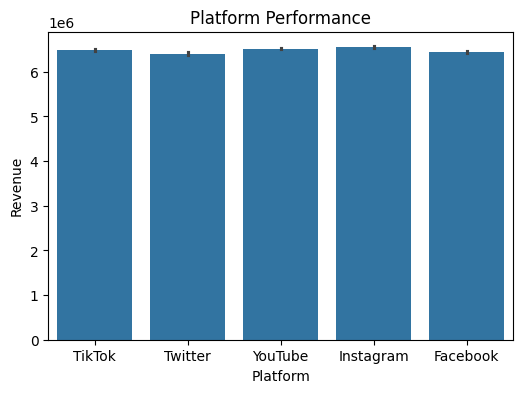

In [12]:
plt.figure(figsize=(6,4))

sns.barplot(x="Platform", y="Revenue", data=df)

plt.title("Platform Performance")
plt.show()

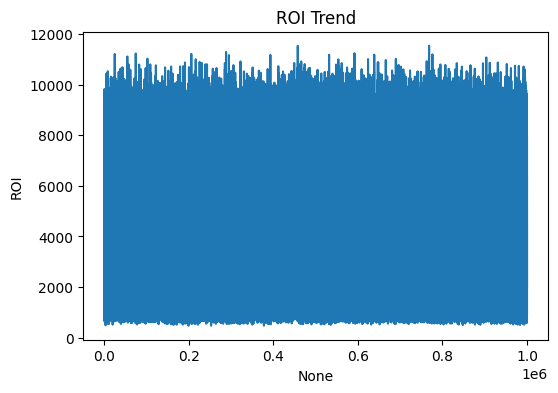

In [13]:
plt.figure(figsize=(6,4))

sns.lineplot(x=df.index, y="ROI", data=df)

plt.title("ROI Trend")
plt.show()
